# Exhibit: Return Predictability

*Workshop 2 exhibit — **Structural Change and Expectations in Macroeconomics and Finance** (University of Copenhagen, Autumn 2026).*

## 1. The relation

Can stock-market returns be predicted? The most-studied candidate predictor is the **dividend–price ratio**: when prices are low relative to dividends, subsequent returns tend to be high, and vice versa. The workhorse **predictive regression** is

$$r_{t+1} = a + b \, \log(D_t/P_t) + \text{error}_{t+1},$$

where $r_{t+1}$ is next year's stock return and $D_t/P_t$ is this year's dividend–price ratio. The stakes are large: $b \ne 0$ says expected returns move over time — a cornerstone question for asset pricing, market efficiency, and anyone deciding when to invest.

The stability of this relation is one of empirical finance's great battlegrounds: Welch and Goyal (2008) showed that most predictors perform poorly out of sample, and much of the debate since is about *parameter instability* in exactly this regression.

**Data:** annual US data, 1927–2021 — S&P index prices and dividends from Robert Shiller's long-run dataset. `ret_next` is next year's total nominal return (%), `log_dp` this year's log dividend–price ratio.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

BLUE, RED, TEAL, GREY = "#006BA2", "#DB444B", "#3EBCD2", "#758D99"
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.alpha": 0.35,
    "axes.titlelocation": "left", "axes.titlesize": 12, "font.size": 11,
})

def load(name):
    try:
        df = pd.read_csv(f"../data/{name}", index_col="year")
    except FileNotFoundError:
        base = "https://raw.githubusercontent.com/mortentabor/structural-change-seminar/main/data/"
        df = pd.read_csv(base + name, index_col="year")
    return df

rp = load("return_predictability.csv").dropna()
rp.tail(3)

,dp,log_dp,ret_next,infl_next,real_ret_next
year,,,,,
2019,0.018333,-3.999041,18.158162,0.013620,16.570466
2020,0.015771,-4.149581,28.139989,0.070364,19.716270
2021,0.012920,-4.348994,-14.877125,0.064544,-20.038182


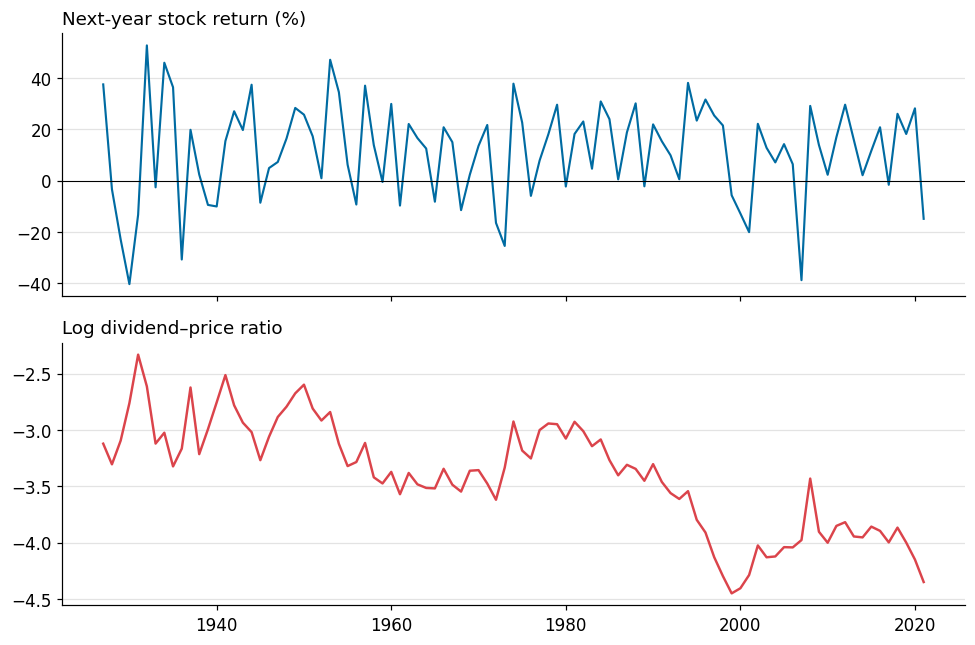

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(rp.index, rp["ret_next"], color=BLUE, lw=1.4)
axes[0].axhline(0, color="black", lw=0.7)
axes[0].set_title("Next-year stock return (%)")
axes[1].plot(rp.index, rp["log_dp"], color=RED, lw=1.6)
axes[1].set_title("Log dividend\u2013price ratio")
plt.tight_layout()
plt.show()

Look at the lower panel before regressing anything: the dividend–price ratio does not fluctuate around one stable level — it *drifts and shifts*, most visibly downward from the 1990s. Keep that in mind.

## 2. The full-sample estimate

In [3]:
def fit_rp(d):
    y = d["ret_next"]
    X = sm.add_constant(d["log_dp"])
    return sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 2})

full = fit_rp(rp)
print(f"Sample: {rp.index.min()}–{rp.index.max()}  (n = {int(full.nobs)})")
print(full.summary().tables[1])
print(f"\nR-squared: {full.rsquared:.3f}")

Sample: 1927–2021  (n = 95)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         32.7735     15.659      2.093      0.036       2.083      63.464
log_dp         6.2635      4.449      1.408      0.159      -2.456      14.984

R-squared: 0.026


The full-sample verdict looks clear: $\hat{b} \approx 6$, **insignificant** (p ≈ 0.16), R² of 3%. Returns are essentially unpredictable — case closed?

## 3. Is it stable? Your turn first

Run the subsample splits below — then **change them** (edit the dictionary, rerun). What happens to $\hat{b}$ *within* periods?

In [4]:
SUBSAMPLES = {
    "1927\u20131956": (1927, 1956),
    "1957\u20131990": (1957, 1990),
    "1991\u20132021": (1991, 2021),
}

rows = []
for name, (start, end) in SUBSAMPLES.items():
    r = fit_rp(rp.loc[start:end])
    rows.append({"sample": name, "b": r.params["log_dp"], "se(b)": r.bse["log_dp"],
                 "p(b)": r.pvalues["log_dp"], "R2": r.rsquared, "n": int(r.nobs)})
pd.DataFrame(rows).round(3)

,sample,b,se(b),p(b),R2,n
0,1927–1956,12.547,11.872,0.291,0.020,30
1,1957–1990,37.696,9.840,0.000,0.240,34
2,1991–2021,28.880,9.629,0.003,0.196,31


### The surprise — and what is behind it

In Workshop 1's exhibit, instability made a full-sample relationship look *significant* when it was absent for forty years. Here it is the **mirror image**: the full sample says "no predictability," yet within the post-1957 subsamples predictability is **strong and highly significant** (R² around 20%!).

How can pooling destroy a relationship that holds within each period? Look again at the dividend–price ratio's plot: its *level* shifted down over time (Lettau and Van Nieuwerburgh 2008 argue: shifts in the ratio's steady state). When the level of the regressor shifts but the within-period relation persists, a full-sample regression mixes the levels and flattens the slope.

**Instability doesn't just fabricate relationships — it can hide them.** Full-sample estimates can mislead in *both* directions.

**A note on formal tests:** the Bai–Perron test (Workshop 3) finds **no statistically significant breaks** in this regression at standard settings — with only 95 annual observations, formally *detecting* the instability you just saw is hard. Detection power in small samples is itself a live research question.

### Check the mechanism yourself

The formal test found no slope breaks — but the story above says the **level of the dividend–price ratio** shifted. That claim you can check in three lines. Run this in a new cell:

```python
for name, (start, end) in SUBSAMPLES.items():
    print(name, round(rp.loc[start:end, "log_dp"].mean(), 2))
```

You should see the regressor's average level shifting down across the periods — while, as your subsample table shows, the *within-period* slopes stay strong. Pooling mixes the levels, and that flattens the full-sample slope.

Then stress-test the finding: move the split years in `SUBSAMPLES` and rerun. Does the within-period predictability survive *your* cuts? Why a slope-break test can miss level shifts in the regressor — and what test would catch them — is Workshop 3 material.

## 4. What could a paper deliver?

You have now seen that the relation is not stable. **That, by itself, is not yet a research question.** "Is X stable? — No" is a finding, not a paper. The interesting paper starts with what you build *on top of* the finding. Four types of questions you can build:

1. **Timing / episodes** — when did the dividend–price ratio's level shift, and what changed in markets then? (Share repurchases replacing dividends? The 1990s tech boom?)
2. **Source / mechanism** — is the instability in the *predictor* (the ratio's steady state) or in the *relation* (the slope)? Those are different papers.
3. **Interpretation / inference** — if pooling hides within-period predictability, what should we conclude from full-sample tests of market efficiency? And what does it mean that a formal break test *can't* see instability in 95 observations?
4. **Consequences / practice** — what does an investor or pension fund lose by using the full-sample estimate? Does out-of-sample forecasting improve if you allow for the level shifts?

**The "This paper…" exercise.** A research question is specific when you can state what the paper *delivers*. Compare (on a relation that is *not* one of today's exhibits):

> *Weak:* "This paper examines whether Okun's law is stable."
>
> *Strong:* "This paper shows that Okun's law held in every US recession since 1960 except 2020, and asks what made the COVID labor market different."

The strong version states a deliverable and why it is interesting — even before the analysis exists.

**Your task (in class):** write one or two **"This paper…"** sentences for this exhibit. Be specific: what does your paper show, ask, or deliver?

## 5. Further reading

If this exhibit grabbed you, start here:

- Welch, I., and Goyal, A. (2008). "A Comprehensive Look at the Empirical Performance of Equity Premium Prediction." *Review of Financial Studies*, 21(4) — the paper that stress-tested the whole predictability literature.
- Lettau, M., and Van Nieuwerburgh, S. (2008). "Reconciling the Return Predictability Evidence." *Review of Financial Studies*, 21(4) — steady-state shifts in the dividend–price ratio as the resolution.
- Paye, B., and Timmermann, A. (2006). "Instability of Return Prediction Models." *Journal of Empirical Finance*, 13(3) — structural-break tests applied to exactly this regression.
- Farmer, L., Schmidt, L., and Timmermann, A. (2023). "Pockets of Predictability." *Journal of Finance*, 78(3) — predictability as a local, episodic phenomenon.
- Rapach, D., Strauss, J., and Zhou, G. (2010). "Out-of-Sample Equity Premium Prediction." *Review of Financial Studies*, 23(2) — can combining forecasts rescue predictability?